In [82]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
def sor_cluster(n, m, w, clusters, max_iter = 10000, tol = 1e-3):
    '''Successive Over-Relaxation method for laplace equation'''
    u = np.zeros((n, m))
    u_new = np.zeros_like(u)
    
    # Set boundary conditions 
    u[0, :] = 1  # Top boundary
    u[-1, :] = 0  # Bottom boundary
    u_new[0, :] = 1  # Top boundary
    u_new[-1, :] = 0  # Bottom boundary
    
    if clusters is not None:
        for (x, y) in clusters:
            u[x, y] = 1  
            u_new[x, y] = 1


    errors = []

    # Iteratively update the solution
    for it in range(max_iter):
        # Update each interior point
        for i in range(1, n - 1):
            for j in range(0, m):
                if clusters is not None and (i, j) in clusters:
                    continue  # Skip cluster points
                jr = (j + 1) % (m - 1)  # right boundary
                jl = (j - 1) % (m - 1)  # left boundary
                u_new[i, j] = 0.25 * w * (u[i+1, j] + u_new[i-1, j] + u[i, jr] + u_new[i, jl]) + (1 -w) * u[i, j]
        u_new[0, :] = 1  # Top boundary
        u_new[-1, :] = 0  # Bottom boundary
        if clusters is not None:
            for (x, y) in clusters:
                u_new[x, y] = 1  

        errors.append(np.max(np.abs(u_new - u)))
        # Check for convergence
        if np.max(np.abs(u_new - u)) < tol:
            print(f'Converged after {it} iterations.')
            break
        
        # Update the solution for the next iteration
        u[:] = u_new[:]
    
    return u, errors

In [84]:
def sor_cluster_oldu(u, w, clusters, max_iter = 10000, tol = 1e-5):
    '''Successive Over-Relaxation method for laplace equation'''
    n, m = u.shape
    
    # Set boundary conditions 
    u[0, :] = 1  # Top boundary
    u[-1, :] = 0  # Bottom boundary
    u_new = np.copy(u)
    if clusters is not None:
        for (x, y) in clusters:
            u[x, y] = 1  
            u_new[x, y] = 1


    errors = []
    for it in range(max_iter):
        # Update each interior point
        for i in range(1, n - 1):
            for j in range(0, m):
                if clusters is not None and (i, j) in clusters:
                    continue  # Skip cluster points
                jr = (j + 1) % (m - 1)  # right boundary
                jl = (j - 1) % (m - 1)  # left boundary
                u_new[i, j] = 0.25 * w * (u[i+1, j] + u_new[i-1, j] + u[i, jr] + u_new[i, jl]) + (1 -w) * u[i, j]
        u_new[0, :] = 1  # Top boundary
        u_new[-1, :] = 0  # Bottom boundary
        if clusters is not None:
            for (x, y) in clusters:
                u_new[x, y] = 1  

        errors.append(np.max(np.abs(u_new - u)))
        # Check for convergence
        if np.max(np.abs(u_new - u)) < tol:
            print(f'Converged after {it} iterations.')
            break
        
        # Update the solution for the next iteration
        u[:] = u_new[:]
    
    return u, errors

In [85]:
def plot_heatmap(arr, title="Heatmap", show=True):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

    im = ax.imshow(
        arr,
        origin="lower",
        extent=[0, 1, 0, 1],
        aspect="auto",
        cmap="plasma",   # same colormap
        vmin=0,          # same min
        vmax=1           # same max
    )

    fig.colorbar(im, ax=ax, label="Concentration")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

    plt.tight_layout()
    if show:
        plt.show()
    plt.close(fig)

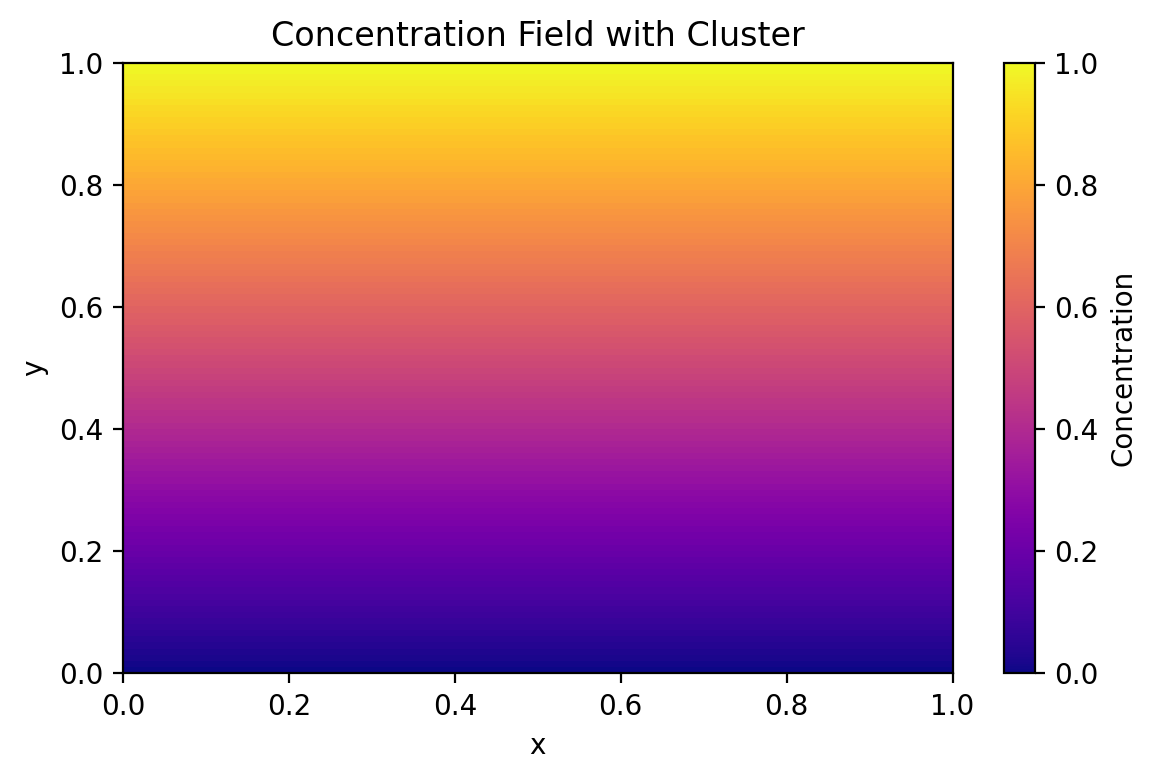

In [103]:
y = np.linspace(0, 1, 100)
u = np.tile(y[:, None], (1, 100))
plot_heatmap(u, title="Concentration Field with Cluster")

In [92]:
def find_growth_candidates(clusters, n, m):
    candidates = set()
    for (x, y) in clusters:
        yl = (y - 1) % (m - 1)
        yr = (y + 1) % (m - 1)
        
        candidates.add((x, yr))  # right
        candidates.add((x, yl))  # left
        if x+1 < n:
            candidates.add((x + 1, y))  # down
        if x-1 >= 0:
            candidates.add((x - 1, y))  # up
    return candidates - clusters

In [104]:
def DLA(n,m,eta,max_particles = 1000,w = 1.8):
    clusters = set([(1, m//2)])  # Start with a seed in the center
    assert eta > 0, "eta must be positive"
    assert 1<= w < 2, "w must be in the range (1, 2)"
    y = np.linspace(0, 1, m)
    u = np.tile(y[:, None], (1, n))  # Initial concentration field
    for _ in range(max_particles):
        u,_ = sor_cluster_oldu(u, w, clusters)
        candidates = list(find_growth_candidates(clusters, n, m))
        p_candidates = {}
        for candidate in candidates:
            c_value = max(u[candidate],0)  # Ensure non-negative
            sum_c = sum(u[c]**eta for c in candidates)
            if sum_c == 0:
                p_candidates[candidate] = 1/len(candidates)
            else:
                p_candidates[candidate] = c_value**eta/sum_c
        new_particle_i = np.random.choice(len(p_candidates.keys()), p=list(p_candidates.values()))
        new_particle = list(p_candidates.keys())[new_particle_i]
        clusters.add(new_particle)
    return clusters

Converged after 945 iterations.
Converged after 0 iterations.
Converged after 19 iterations.
Converged after 19 iterations.
Converged after 19 iterations.
Converged after 0 iterations.
Converged after 0 iterations.
Converged after 26 iterations.
Converged after 0 iterations.
Converged after 23 iterations.
Converged after 24 iterations.
Converged after 25 iterations.
Converged after 30 iterations.
Converged after 0 iterations.
Converged after 14 iterations.
Converged after 17 iterations.
Converged after 0 iterations.
Converged after 13 iterations.
Converged after 30 iterations.
Converged after 45 iterations.
Converged after 41 iterations.
Converged after 34 iterations.
Converged after 24 iterations.
Converged after 19 iterations.
Converged after 50 iterations.
Converged after 34 iterations.
Converged after 28 iterations.
Converged after 18 iterations.
Converged after 22 iterations.
Converged after 41 iterations.
Converged after 8 iterations.
Converged after 42 iterations.
Converged afte

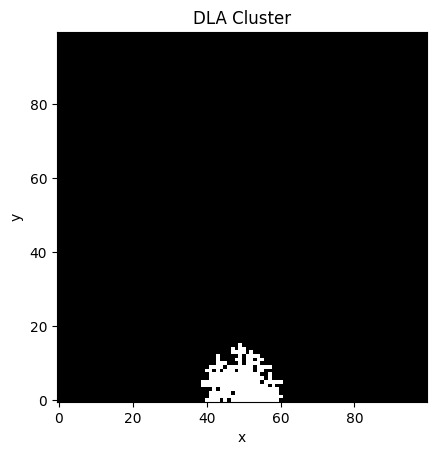

In [105]:
clusters = DLA(100, 100, eta=1, max_particles=200)
grid = np.zeros((100, 100))
for (x, y) in clusters:
    grid[x, y] = 1
plt.imshow(grid, origin='lower', cmap='gray')
plt.title("DLA Cluster")
plt.xlabel("x")
plt.ylabel("y")
plt.show()  

Converged after 945 iterations.
Converged after 20 iterations.
Converged after 26 iterations.
Converged after 24 iterations.
Converged after 0 iterations.
Converged after 32 iterations.
Converged after 47 iterations.
Converged after 3 iterations.
Converged after 0 iterations.
Converged after 22 iterations.
Converged after 10 iterations.
Converged after 0 iterations.
Converged after 23 iterations.
Converged after 24 iterations.
Converged after 4 iterations.
Converged after 25 iterations.
Converged after 26 iterations.
Converged after 0 iterations.
Converged after 0 iterations.
Converged after 22 iterations.
Converged after 18 iterations.
Converged after 26 iterations.
Converged after 8 iterations.
Converged after 29 iterations.
Converged after 25 iterations.
Converged after 23 iterations.
Converged after 30 iterations.
Converged after 37 iterations.
Converged after 23 iterations.
Converged after 34 iterations.
Converged after 53 iterations.
Converged after 41 iterations.
Converged after

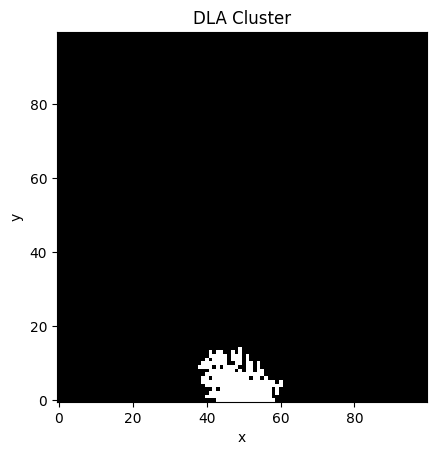

In [106]:
clusters = DLA(100, 100, eta=2, max_particles=200)
grid = np.zeros((100, 100))
for (x, y) in clusters:
    grid[x, y] = 1
plt.imshow(grid, origin='lower', cmap='gray')
plt.title("DLA Cluster")
plt.xlabel("x")
plt.ylabel("y")
plt.show()  